In [34]:
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt
import SimpleITK as sitk
import skimage
import pandas as pd
import numpy.ma as ma
import os
from pathlib import Path
import skimage.measure as measure
from skimage import data, img_as_float
from skimage import morphology
from skimage.measure import regionprops
from scipy.ndimage import label, generate_binary_structure
import cv2
from IPython.display import display
from totalsegmentator.python_api import totalsegmentator
import torch

In [35]:
def _binary_threshold_np(img, low, high):
    arr = np.asarray(img)
    out = np.zeros(arr.shape, dtype=np.uint8)
    m = np.isfinite(arr)
    out[m] = ((arr[m] >= low) & (arr[m] <= high)).astype(np.uint8)
    return out

def _remove_small_objects_np(mask, min_size):
    lab = morphology.label(mask)
    cleaned = morphology.remove_small_objects(lab, min_size)
    return (cleaned > 0).astype(np.uint8)

def _floodfill_np(mask):
    arr = np.asarray(mask, dtype=np.uint8)
    h, w = arr.shape
    ff = arr.copy()
    m = np.zeros((h+2, w+2), np.uint8)
    cv2.floodFill(ff, m, (0,0), 255)
    inv = (cv2.bitwise_not(ff) > 0).astype(np.uint8)
    return inv

def _dilate_np(mask, kernel, it):
    m = np.asarray(mask, dtype=np.uint8)
    k = np.asarray(kernel, dtype=np.uint8)
    i = int(np.asarray(it, dtype=np.uint8))
    return cv2.dilate(m, k, iterations=i)

def _erode_np(mask, kernel, it):
    m = np.asarray(mask, dtype=np.uint8)
    k = np.asarray(kernel, dtype=np.uint8)
    i = int(np.asarray(it, dtype=np.uint8))
    return cv2.erode(m, k, iterations=i)

def clean_mask_hip_visualize(ct_arr, ct_cropped, hip_mask, slice_to_visualize=None, dilate_kernel=None, dilate_iters=1, erode_iters=1):
    if dilate_kernel is None:
        dilate_kernel = np.array([[0,1,0],[1,1,1],[0,1,0]], dtype=np.uint8)

    zdim = hip_mask.shape[0]
    refined_mask = hip_mask.copy()

    # Find inferior bound of acetabulum corresponding to 0.6 cm below the upper border of obturator foramen
    # The longest run of slices > 2 objects correspond to obturator foramen
    max_len = 0
    current_len = 0
    end_idx = -1
    for z in range(zdim):
        cleaned_slice = _remove_small_objects_np(hip_mask[z], min_size=100)
        _, count = label(cleaned_slice)
        if count >= 2:
            current_len += 1
            if current_len > max_len:
                max_len = current_len
                end_idx = z
        else:
            current_len = 0

    if max_len > 0:
        start_idx = end_idx - max_len + 1
        print(f"Longest run of slices with ≥2 objects: {max_len} slices (z={start_idx} to z={end_idx})")
        print(f"Most superior slice of obturator foramen: z={end_idx}")
    
        inferior_bound = max(end_idx - 3, 0)
        print(f"Inferior bound: z={inferior_bound}")
    else:
        print("Obturator foramen not detected -- falling back to most inferior non-empty slice.")
        
        inferior_bound = None
        for z in range(zdim):
            cleaned_slice = _remove_small_objects_np(hip_mask[z], min_size=100)
            if np.any(cleaned_slice):
                inferior_bound = z
                break
                
        if inferior_bound is None:
            print("Hip bone mask is empty -- returning original mask.")
            return refined_mask

        print(f"Inferior bound (fallback): z={inferior_bound}")

    # Find superior bound corresponding to 0.9 cm above the acetabular roof
    # The first slice with > 0.9 solidity corresponds to acetabular roof
    superior_bound = None
    for z in range(end_idx + 1, zdim):
        labeled, _ = label(hip_mask[z])
        props = regionprops(labeled)
        if props:
            largest_region = max(props, key=lambda r: r.area)
            solidity = largest_region.solidity
        else:
            solidity = 0.0

        if solidity > 0.9:
            superior_bound = z + 6
            if superior_bound >= zdim:
                superior_bound = zdim - 1
            print(f"Acetabular roof at slice {z}, setting superior bound = {superior_bound}")
            break

    if superior_bound is None:
        superior_bound = inferior_bound + 34
        if superior_bound >= zdim:
            superior_bound = zdim - 1
        print("No slice with solidity > 0.9 found. Forcing range to be 34.")

    print(f"Cleaning range: z={inferior_bound} to z={superior_bound}")
    
    # Sanity check: valid cleaning range should be within 4.2-6.0 cm
    cleaning_range = superior_bound - inferior_bound
    if cleaning_range < 28 or cleaning_range > 40:
        print(f"Warning: suspicious acetabular roof identification with {cleaning_range} slices of acetabulum. Forcing range to be 34.")
        superior_bound = inferior_bound + 34
        if superior_bound >= zdim:
            superior_bound = zdim - 1

    print(f"Cleaning range: z={inferior_bound} to z={superior_bound}")
    
    # Clean selected slices
    for i in range(inferior_bound, min(superior_bound + 1, zdim)):
        slice_crop = ct_cropped[i]
        slice_ct = ct_arr[i]

        # Apply binary thresholding
        mask_bi = _binary_threshold_np(slice_crop, low=150, high=np.inf)

        # HU-based expansion
        max_added_voxels = 40  # sanity cap per slice
        high_hu = slice_ct > 300
        labeled_high, num_high = label(high_hu.astype(np.uint8))
    
        if num_high > 0:
            touching_labels = np.unique(labeled_high[mask_bi.astype(bool)])
            touching_labels = touching_labels[touching_labels != 0]
    
            if touching_labels.size > 0:
                connected_high = np.isin(labeled_high, touching_labels)
                expanded_mask = mask_bi.astype(bool) | connected_high
                added_voxels = (np.count_nonzero(expanded_mask) - np.count_nonzero(mask_bi))
                
                if added_voxels <= max_added_voxels:
                    mask_exp = expanded_mask.astype(np.uint8)
                else:
                    print(
                        f"Slice {i}: HU-based expansion added {added_voxels} voxels "
                        f"(> {max_added_voxels}); reverting to mask after binary thresholding."
                    )
                    mask_exp = mask_bi
            else:
                mask_exp = mask_bi
        else:
            mask_exp = mask_bi
        mask_dil = _dilate_np(mask_exp, dilate_kernel, dilate_iters)
        mask_erod = _erode_np(mask_dil, dilate_kernel, erode_iters)
        mask_fill = _floodfill_np(mask_erod)
        refined_mask[i] = mask_fill

        # Histogram for binary thresholding
        if i == slice_to_visualize:
            flat_vals = slice_crop.ravel()
            flat_vals = flat_vals[np.isfinite(flat_vals)]                      
            plt.figure(figsize=(8, 5))
            plt.hist(flat_vals, bins=100)
            plt.axvline(
                150,
                color="red",
                linestyle="--",
                linewidth=2,
                label=f"Binary threshold = 150"
            )

            plt.axvspan(-200, 150, color="red", alpha=0.12)
            plt.xlim(-200, 1000)
            plt.ylim(0,None)
            plt.title(f"HU Value Distribution for a Single Slice")
            plt.xlabel("CT Intensity (HU)")
            plt.ylabel("Number of Voxels")
            plt.legend()
            plt.show()

            # Mask visualization after each step
            fig, axes = plt.subplots(5, 1, figsize=(10, 25))
            stages = [
                ("Original Mask", hip_mask[i]),
                ("Binary Thresholding", mask_bi),
                ("HU-based Expansion", mask_exp),
                ("Morphological Closing", mask_erod),
                ("Floodfilling", mask_fill)
            ]

            wl = 500
            ww = 2000
            vmin = wl - ww / 2
            vmax = wl + ww / 2
            alpha = 0.3

            for j, (title, mask) in enumerate(stages):
                axes[j].imshow(slice_ct, cmap='bone', vmin=vmin, vmax=vmax)
                axes[j].imshow(mask, cmap='rainbow', alpha=alpha * mask, interpolation='none')
                axes[j].set_title(title)
                axes[j].axis('off')
               
            plt.tight_layout()
            plt.show()
            
    # 3D connectivity: keep only the largest connected component
    structure = generate_binary_structure(3, 1)
    labeled_3d, num = label(refined_mask.astype(bool), structure=structure)
    print(f"3D connected components found: {num}")
    if num == 0:
        print("Warning: refined hip mask is empty after 3D labeling.")
        return refined_mask
        
    counts = np.bincount(labeled_3d.ravel())
    counts[0] = 0
        
    largest_label = counts.argmax()
    refined_mask = (labeled_3d == largest_label).astype(np.uint8)
    return refined_mask

def process_image(input_path):
    # Image loading and processing
    nifti_path = os.path.join(input_path, 'ct.nii.gz')
    output_path = input_path
    ct_nii = nib.load(nifti_path)
    shape = ct_nii.shape
    print("Shape:", shape)
    affine = ct_nii.affine
    spacing = tuple(abs(affine[i, i]) for i in range(3))
    print("Spacing (x, y, z):", spacing)
    
    # Convert to NumPy array and mandate orientation
    ct_arr_init = ct_nii.get_fdata()
    init_axcodes = nib.aff2axcodes(affine)
    print("Initial orientation:", init_axcodes)
    target_axcodes = ('L', 'P', 'S')
    ornt_init = nib.orientations.axcodes2ornt(init_axcodes)
    ornt_target = nib.orientations.axcodes2ornt(target_axcodes)
    ornt_transf = nib.orientations.ornt_transform(ornt_init, ornt_target)
    ct_arr_lps = nib.orientations.apply_orientation(ct_arr_init, ornt_transf)
    ct_arr = np.transpose(ct_arr_lps, axes=(2, 1, 0))
    
    # Run TotalSegmentator
    right_hip_pred = totalsegmentator(nifti_path, input_path, task="total", roi_subset=["hip_right"],  fast=False, ml=False, device="gpu", skip_saving=False)
    left_hip_pred  = totalsegmentator(nifti_path, input_path, task="total", roi_subset=["hip_left"],   fast=False, ml=False, device="gpu", skip_saving=False)
    # Get segmentation arrays
    right_hip_pred_arr_init = right_hip_pred.get_fdata()
    left_hip_pred_arr_init = left_hip_pred.get_fdata()
    # Correct orientation  
    right_hip_pred_arr_lps = nib.orientations.apply_orientation(right_hip_pred_arr_init, ornt_transf)
    left_hip_pred_arr_lps = nib.orientations.apply_orientation(left_hip_pred_arr_init, ornt_transf)
    # Transpose merged mask    
    right_hip_pred_arr_rev = np.transpose(right_hip_pred_arr_lps, axes=(2, 1, 0))
    left_hip_pred_arr_rev = np.transpose(left_hip_pred_arr_lps, axes=(2, 1, 0))
    # Create cropped image
    right_hip_cropped = np.where(right_hip_pred_arr_rev == 78, ct_arr, np.nan)
    left_hip_cropped = np.where(left_hip_pred_arr_rev == 77, ct_arr, np.nan)
    # Create binary mask
    right_hip_pred_arr_rev_bi = (right_hip_pred_arr_rev == 78).astype(np.uint8)
    left_hip_pred_arr_rev_bi  = (left_hip_pred_arr_rev  == 77).astype(np.uint8)

    return ct_arr, right_hip_pred_arr_rev_bi, left_hip_pred_arr_rev_bi, right_hip_cropped, left_hip_cropped

def print_solidity(hip_mask):
    zdim = hip_mask.shape[0]

    for z in range(zdim):
        mask_slice = hip_mask[z]
        labeled_slice, _ = label(mask_slice)  
        props = regionprops(labeled_slice)    
    
        if props:
            largest = max(props, key=lambda r: r.area)
            solidity = largest.solidity
        else:
            solidity = 0.0
    
        print(f"Slice {z}: Solidity = {solidity:.3f}")

In [36]:
# Load and process images for display
ct_arr_s0358, right_hip_pred_arr_rev_bi_s0358, left_hip_pred_arr_rev_bi_s0358, right_hip_cropped_s0358, left_hip_cropped_s0358 = process_image(os.path.join(os.getcwd(), r'Images\Totalsegmentator_dataset_small_v201\s0358-metal-right'))
ct_arr_s0011, right_hip_pred_arr_rev_bi_s0011, left_hip_pred_arr_rev_bi_s0011, right_hip_cropped_s0011, left_hip_cropped_s0011 = process_image(os.path.join(os.getcwd(), r'Images\Totalsegmentator_dataset_small_v201\s0011'))

Shape: (255, 255, 523)
Spacing (x, y, z): (np.float64(1.5), np.float64(1.5), np.float64(1.5))
Initial orientation: ('R', 'A', 'S')

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 5.89s
Predicting...


100%|██████████| 4/4 [00:00<00:00, 77.30it/s]


  Predicted in 15.01s
Resampling...
  cropping from (255, 255, 523) to (119, 123, 159)
Resampling...
  Resampled in 0.01s
Predicting part 1 of 1 ...


100%|██████████| 2/2 [00:00<00:00, 57.63it/s]


  Predicted in 14.67s
Resampling...
Saving segmentations...
  Saved in 10.82s

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 4.89s
Predicting...


...

  Predicted in 14.61s
Resampling...
Saving segmentations...
  Saved in 11.31s

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
Resampling...
  Resampled in 1.97s
Predicting...


100%|██████████| 12/12 [00:00<00:00, 122.77it/s]


  Predicted in 14.66s
Resampling...
  cropping from (311, 311, 431) to (118, 123, 152)
Resampling...
  Resampled in 0.00s
Predicting part 1 of 1 ...


100%|██████████| 2/2 [00:00<00:00, 69.42it/s]


  Predicted in 15.29s
Resampling...
Saving segmentations...
  Saved in 12.11s


C:\Users\15510\AppData\Local\Temp\ipykernel_37572\2890587325.py:10: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = morphology.remove_small_objects(lab, min_size)


Longest run of slices with ≥2 objects: 17 slices (z=20 to z=36)
Most superior slice of obturator foramen: z=36
Inferior bound: z=33
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=33 to z=68
Cleaning range: z=33 to z=68


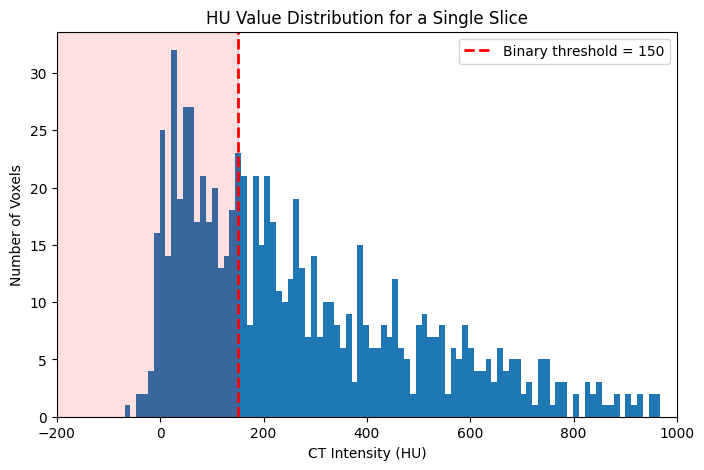

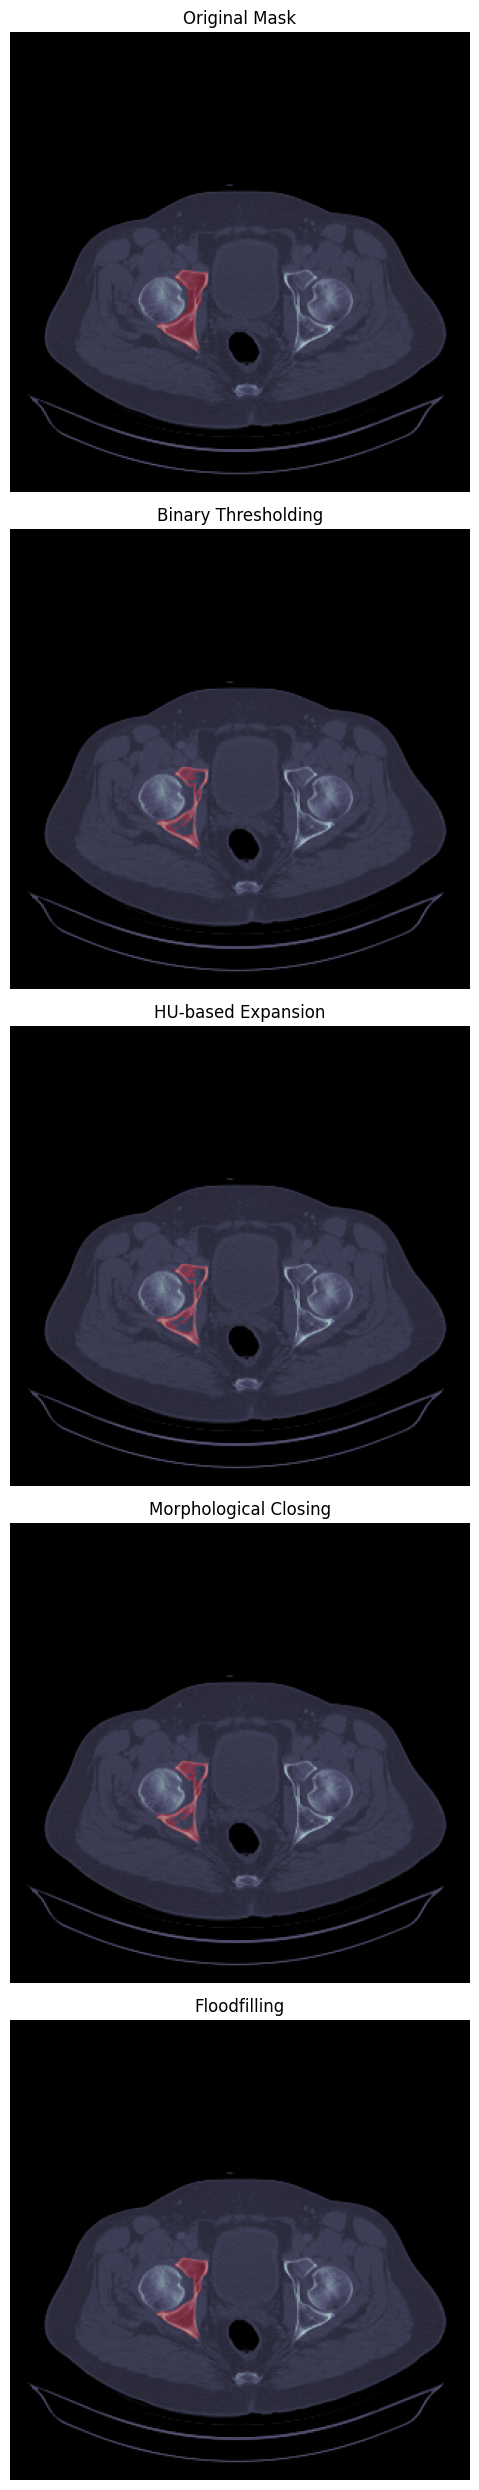

3D connected components found: 5


In [37]:
# Representative image: s0011-right (slice 50)
# - Original mask: over-segmentation of the acetabular fossa
# - Binary thresholding: cortical bone remains intact after thresholding    
# - Expansion: minimal (added voxels = 1)
# - Morph close and floodfilling: default workflow works fine 
# - Not replaced by fallback morph close method: voxel count difference (fallback - default) = 7
# - Not replaced by original mask: voxel count difference (original - processed) = 99
%matplotlib inline
right_hip_mask_cleaned_s0011 = clean_mask_hip_visualize(ct_arr_s0011, right_hip_cropped_s0011, right_hip_pred_arr_rev_bi_s0011, slice_to_visualize=50, dilate_kernel=None, dilate_iters=1, erode_iters=1)

C:\Users\15510\AppData\Local\Temp\ipykernel_37572\2890587325.py:10: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = morphology.remove_small_objects(lab, min_size)


Longest run of slices with ≥2 objects: 17 slices (z=21 to z=37)
Most superior slice of obturator foramen: z=37
Inferior bound: z=34
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=34 to z=68
Cleaning range: z=34 to z=68


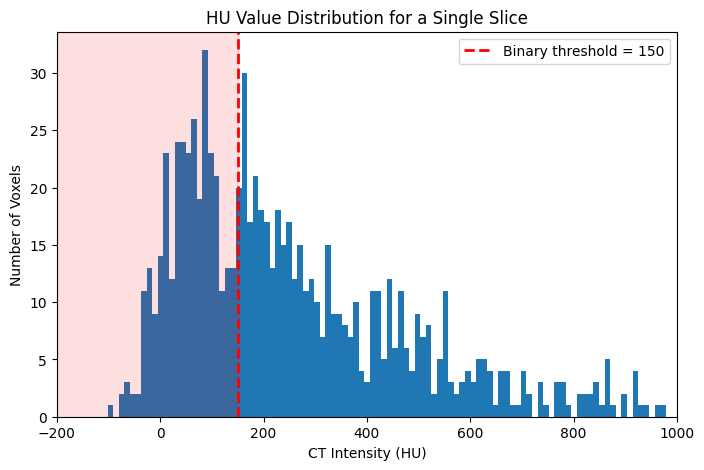

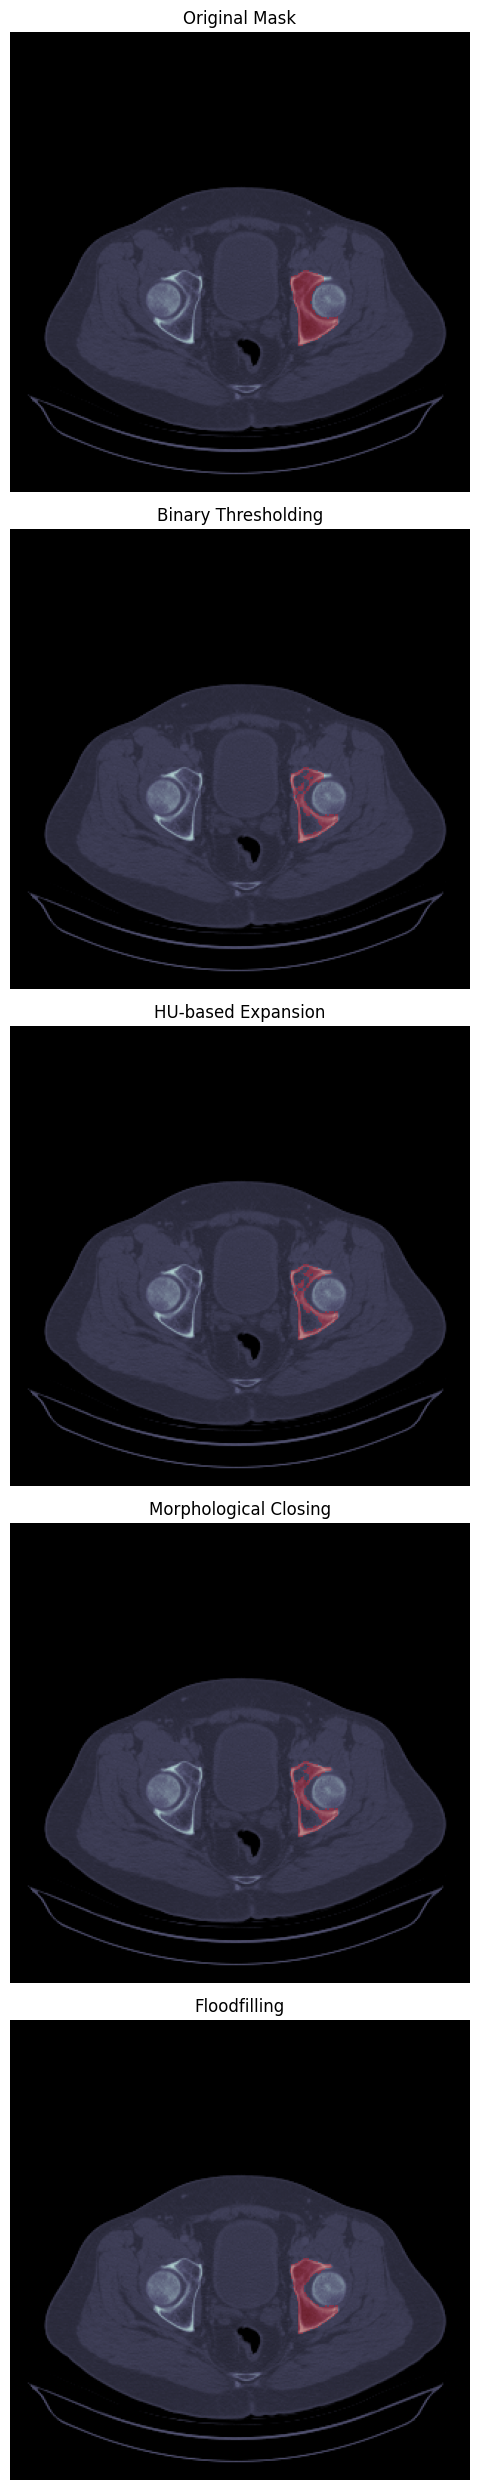

Slice 61: HU-based expansion added 90 voxels (> 40); reverting to mask after binary thresholding.
3D connected components found: 2


In [38]:
# Representative image: s0011-left (slice 57)
# - Original mask: missed acetabular rim; over-segmentation of the acetabular fossa
# - Binary thresholding: small gap in cortical bone    
# - Expansion: acetabular rim captured and added to the mask (added voxels = 17)
# - Morph close and floodfilling: default workflow works fine 
# - Not replaced by fallback morph close method: voxel count difference (fallback - default) = 0
# - Not replaced by original mask: voxel count difference (original - processed) = 63
left_hip_mask_cleaned_s0011 = clean_mask_hip_visualize(ct_arr_s0011, left_hip_cropped_s0011, left_hip_pred_arr_rev_bi_s0011, slice_to_visualize=57, dilate_kernel=None, dilate_iters=1, erode_iters=1)

C:\Users\15510\AppData\Local\Temp\ipykernel_37572\2890587325.py:10: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = morphology.remove_small_objects(lab, min_size)


Longest run of slices with ≥2 objects: 17 slices (z=21 to z=37)
Most superior slice of obturator foramen: z=37
Inferior bound: z=34
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=34 to z=68
Cleaning range: z=34 to z=68
Slice 61: HU-based expansion added 90 voxels (> 40); reverting to mask after binary thresholding.


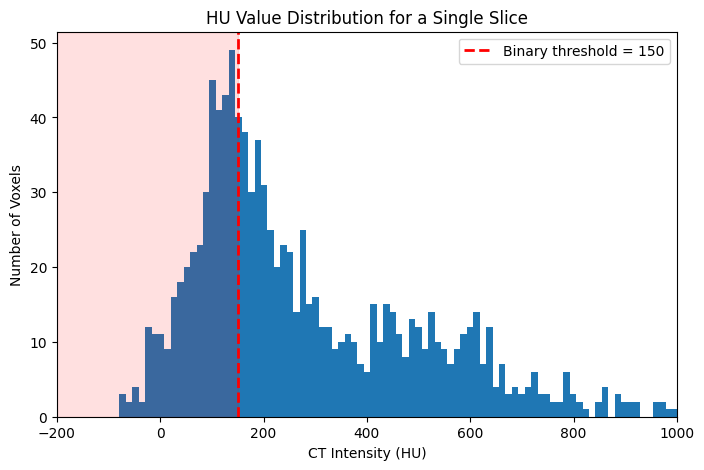

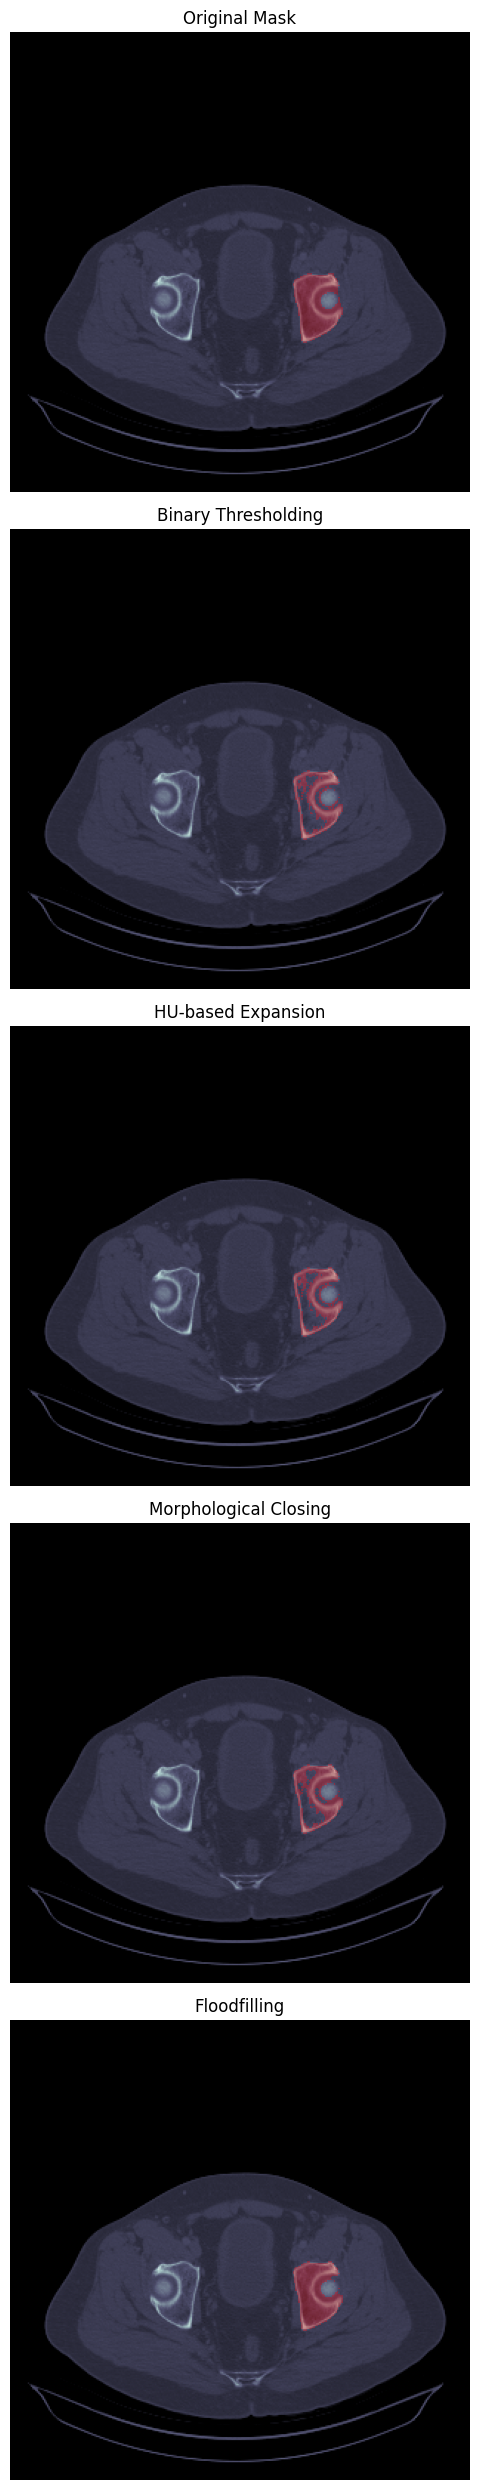

3D connected components found: 2


In [39]:
# Representative image: s0011-left (slice 61)
# - Original mask: significant over-segmentation along the acetabulum; femoral head almost enclosed
# - Binary thresholding: residual high density voxels in the joint cavity from femoral head 
# - Expansion: reverted back due to undesired inclusion of femoral head (added voxels = 90)
# - Morph close and floodfilling: default workflow works fine 
# - Not replaced by fallback morph close method: voxel count difference (fallback - default) = 13
# - Not replaced by original mask: voxel count difference (original - processed) = 32
left_hip_mask_cleaned_s0011 = clean_mask_hip_visualize(ct_arr_s0011, left_hip_cropped_s0011, left_hip_pred_arr_rev_bi_s0011, slice_to_visualize=61, dilate_kernel=None, dilate_iters=1, erode_iters=1)

C:\Users\15510\AppData\Local\Temp\ipykernel_37572\2890587325.py:10: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = morphology.remove_small_objects(lab, min_size)


Longest run of slices with ≥2 objects: 17 slices (z=21 to z=37)
Most superior slice of obturator foramen: z=37
Inferior bound: z=34
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=34 to z=68
Cleaning range: z=34 to z=68


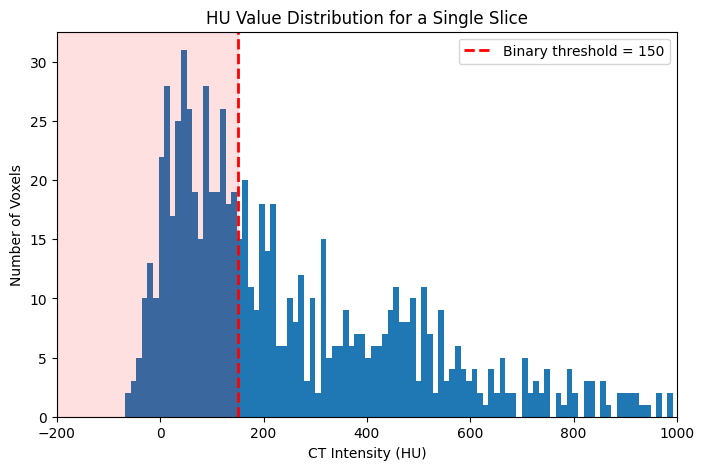

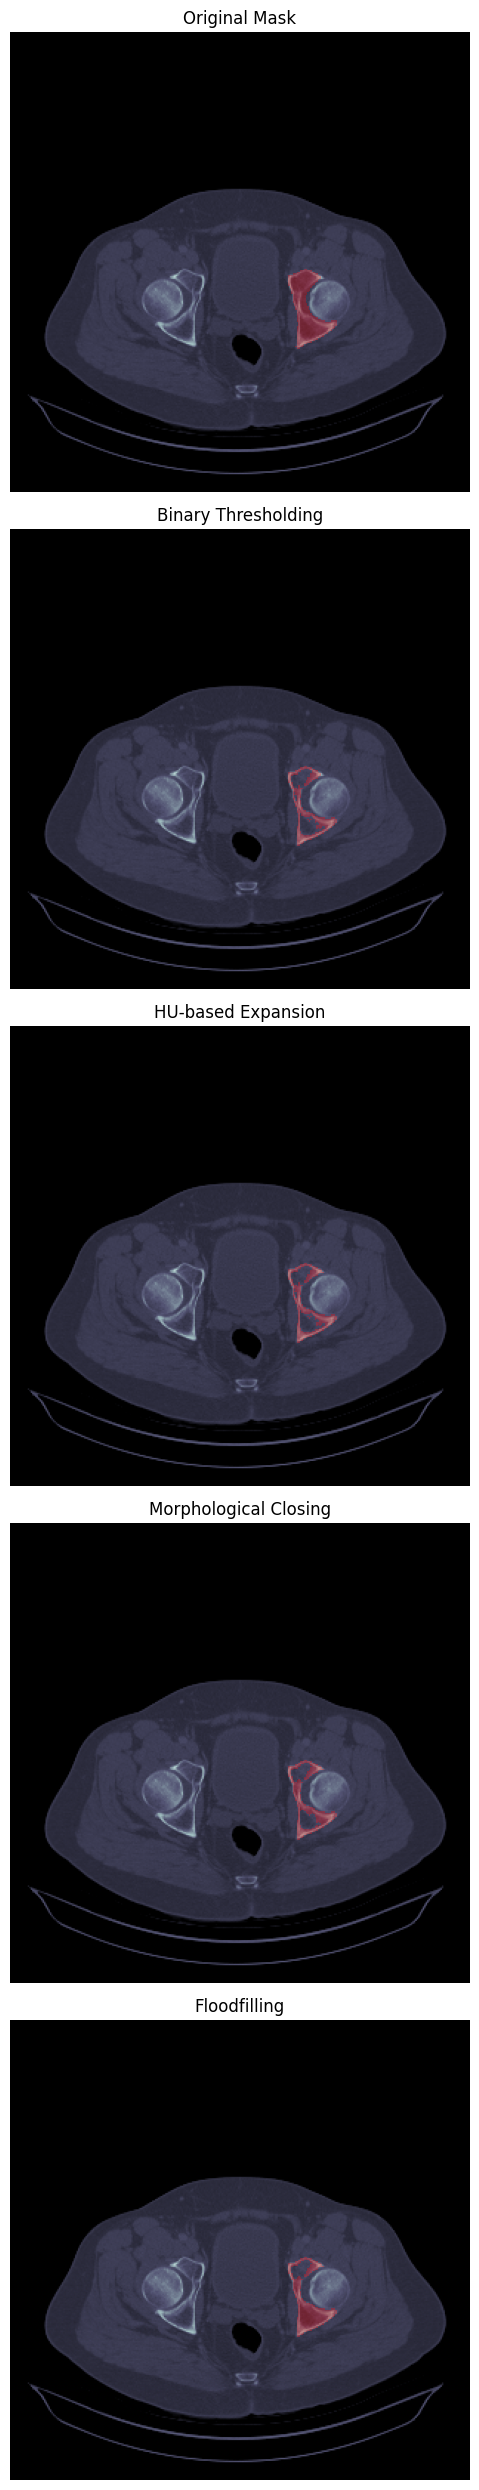

Slice 61: HU-based expansion added 90 voxels (> 40); reverting to mask after binary thresholding.
3D connected components found: 2
Longest run of slices with ≥2 objects: 17 slices (z=21 to z=37)
Most superior slice of obturator foramen: z=37
Inferior bound: z=34
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=34 to z=68
Cleaning range: z=34 to z=68


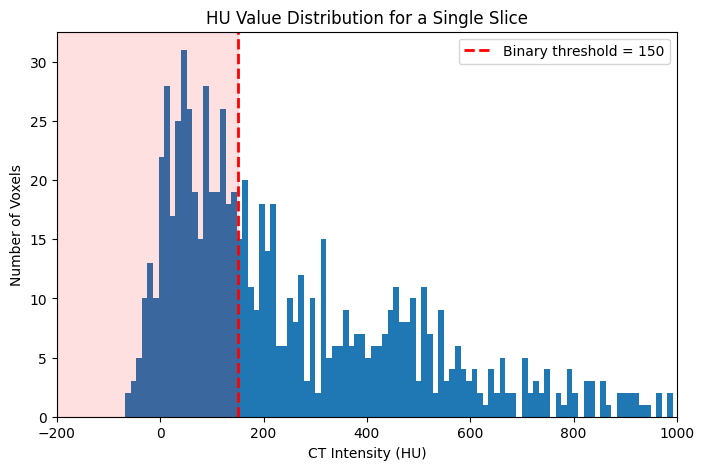

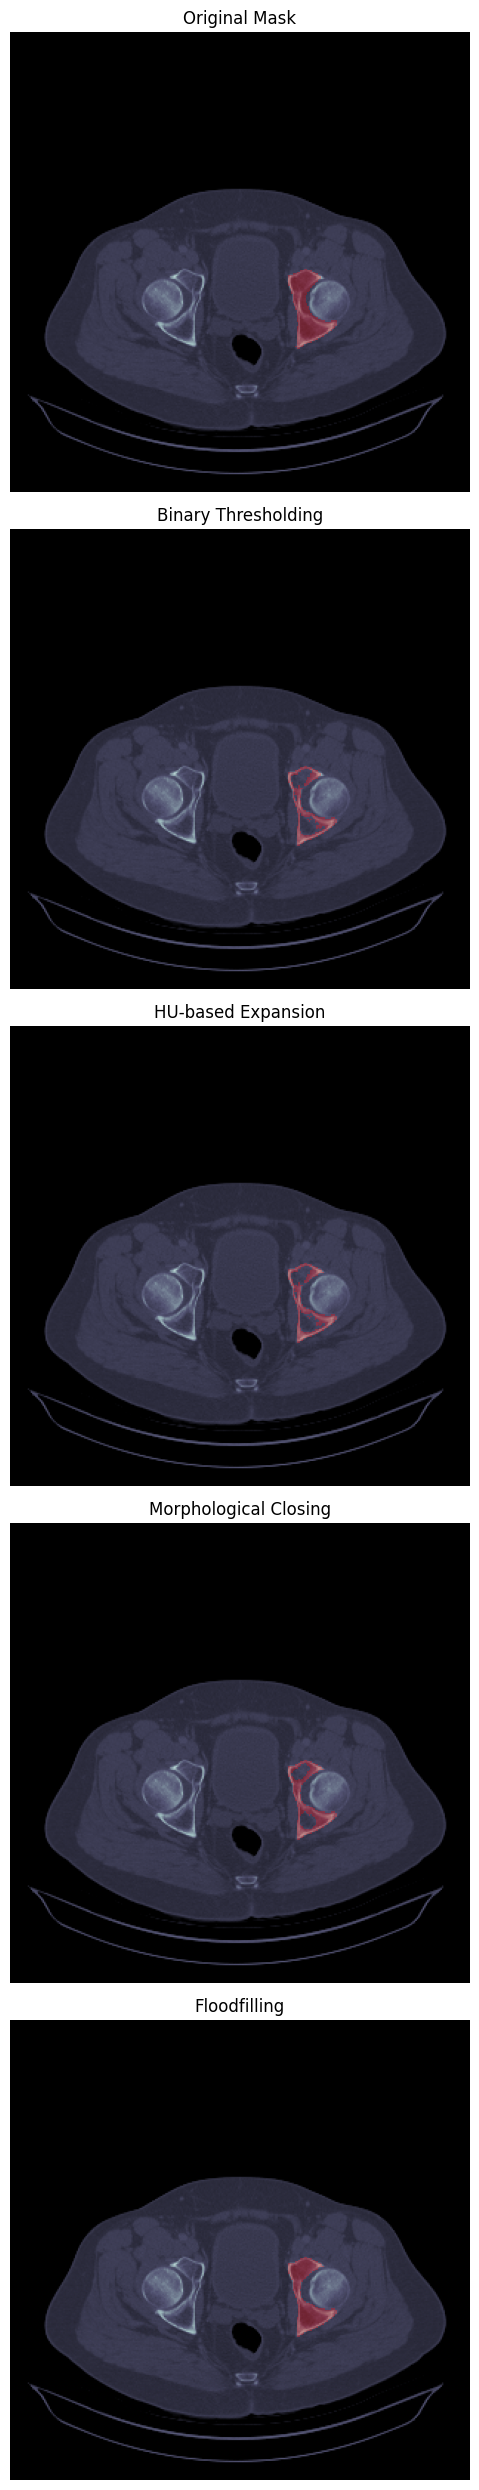

Slice 61: HU-based expansion added 90 voxels (> 40); reverting to mask after binary thresholding.
3D connected components found: 1


In [40]:
# Representative image: s0011-left (slice 54)
# - Original mask: over-segmentation of the acetabular fossa
# - Binary thresholding: large gap in cortical bone 
# - Expansion: minimal (added voxels = 4)
# - Morph close and floodfilling: default workflow fails to close the gap and triggers override by fallback workflow  
# - Replaced by fallback morph close method: voxel count difference (fallback - default) = 112
# - Not replaced by original mask: voxel count difference (original - processed) = 89
left_hip_mask_cleaned_s0011 = clean_mask_hip_visualize(ct_arr_s0011, left_hip_cropped_s0011, left_hip_pred_arr_rev_bi_s0011, slice_to_visualize=54, dilate_kernel=None, dilate_iters=1, erode_iters=1)
left_hip_mask_cleaned_fallback_s0011 = clean_mask_hip_visualize(ct_arr_s0011, left_hip_cropped_s0011, left_hip_pred_arr_rev_bi_s0011, slice_to_visualize=54, dilate_kernel=None, dilate_iters=3, erode_iters=3)

C:\Users\15510\AppData\Local\Temp\ipykernel_37572\2890587325.py:10: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = morphology.remove_small_objects(lab, min_size)


Longest run of slices with ≥2 objects: 17 slices (z=20 to z=36)
Most superior slice of obturator foramen: z=36
Inferior bound: z=33
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=33 to z=68
Cleaning range: z=33 to z=68


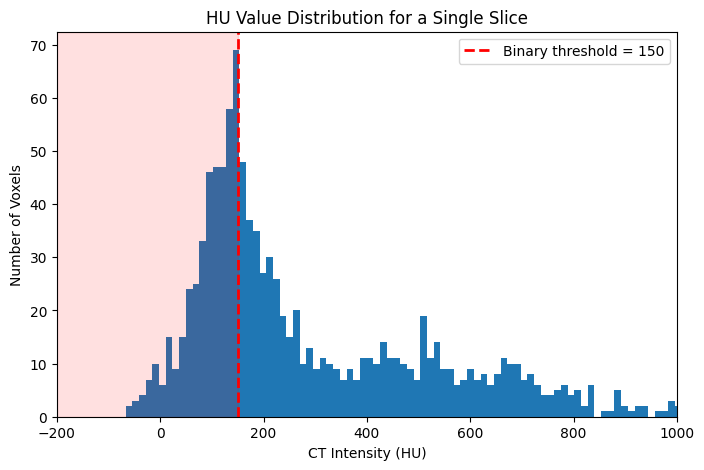

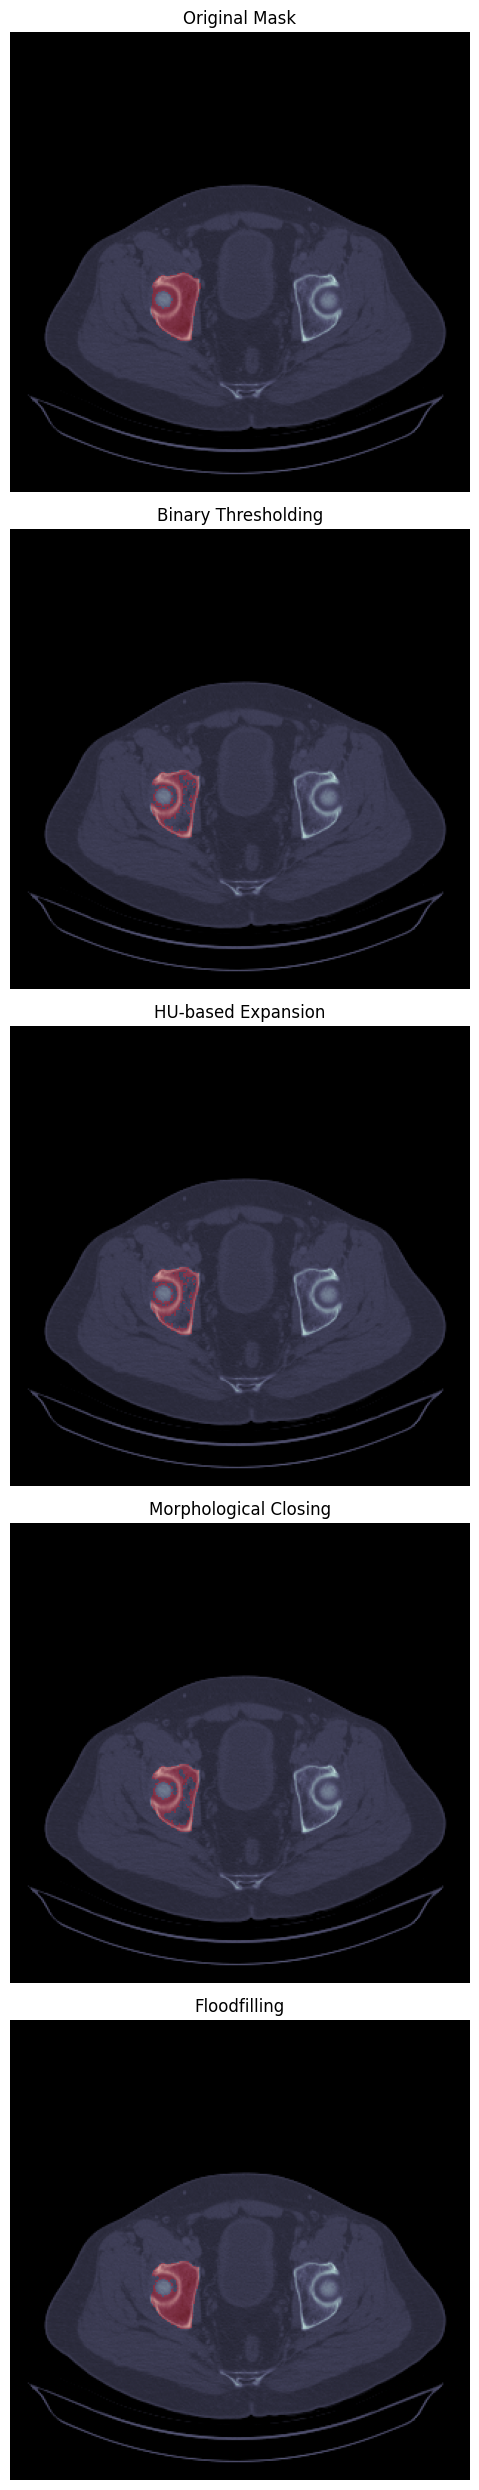

3D connected components found: 5
Longest run of slices with ≥2 objects: 17 slices (z=20 to z=36)
Most superior slice of obturator foramen: z=36
Inferior bound: z=33
Acetabular roof at slice 62, setting superior bound = 68
Cleaning range: z=33 to z=68
Cleaning range: z=33 to z=68


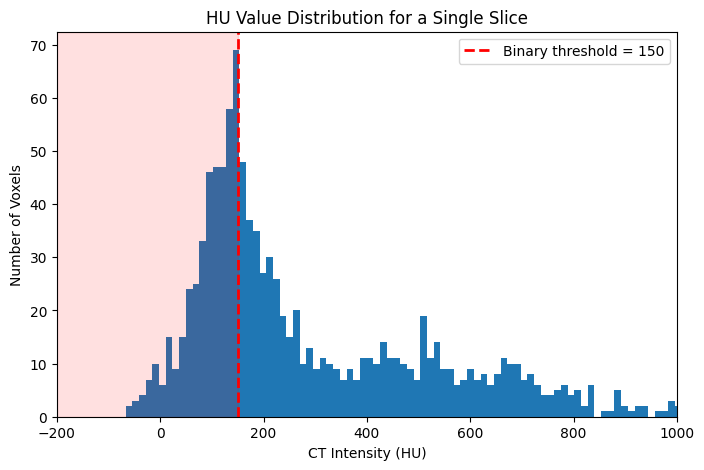

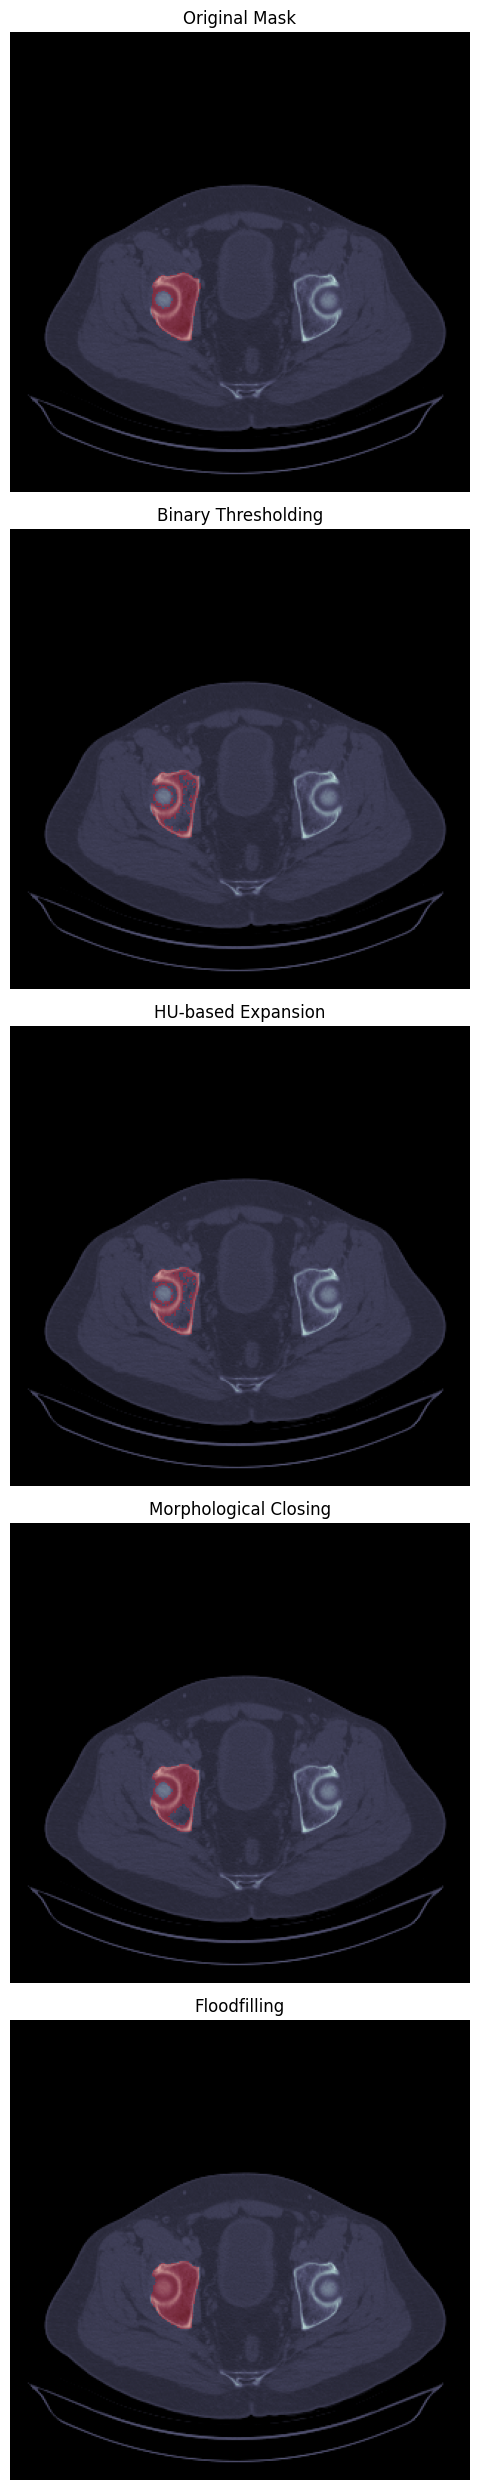

3D connected components found: 1


In [41]:
# Representative image: s0011-right (slice 61)
# - Original mask: significant over-segmentation along the acetabulum; femoral head fully enclosed
# - Binary thresholding: residual high density voxels in the joint cavity from femoral head 
# - Expansion: minimal (added voxels = 1)
# - Morph close and floodfilling: fallback workflow fills up enclosed space corrsponding to the femoral head 
# - Replaced by fallback morph close method: voxel count difference (fallback - default) = 127
# - Replaced by original mask: voxel count difference (original - processed) = -71
right_hip_mask_cleaned_s0011 = clean_mask_hip_visualize(ct_arr_s0011, right_hip_cropped_s0011, right_hip_pred_arr_rev_bi_s0011, slice_to_visualize=61, dilate_kernel=None, dilate_iters=1, erode_iters=1)
right_hip_mask_cleaned_fallback_s0011 = clean_mask_hip_visualize(ct_arr_s0011, right_hip_cropped_s0011, right_hip_pred_arr_rev_bi_s0011, slice_to_visualize=61, dilate_kernel=None, dilate_iters=3, erode_iters=3)

C:\Users\15510\AppData\Local\Temp\ipykernel_37572\2890587325.py:10: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  cleaned = morphology.remove_small_objects(lab, min_size)


Longest run of slices with ≥2 objects: 18 slices (z=154 to z=171)
Most superior slice of obturator foramen: z=171
Inferior bound: z=168
Acetabular roof at slice 192, setting superior bound = 198
Cleaning range: z=168 to z=198
Cleaning range: z=168 to z=198


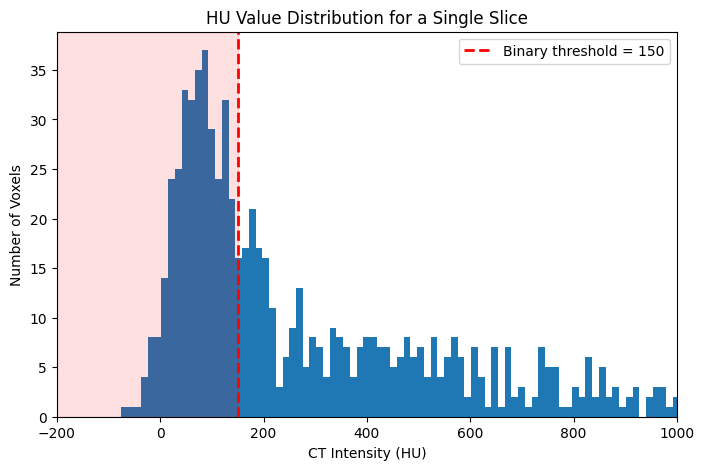

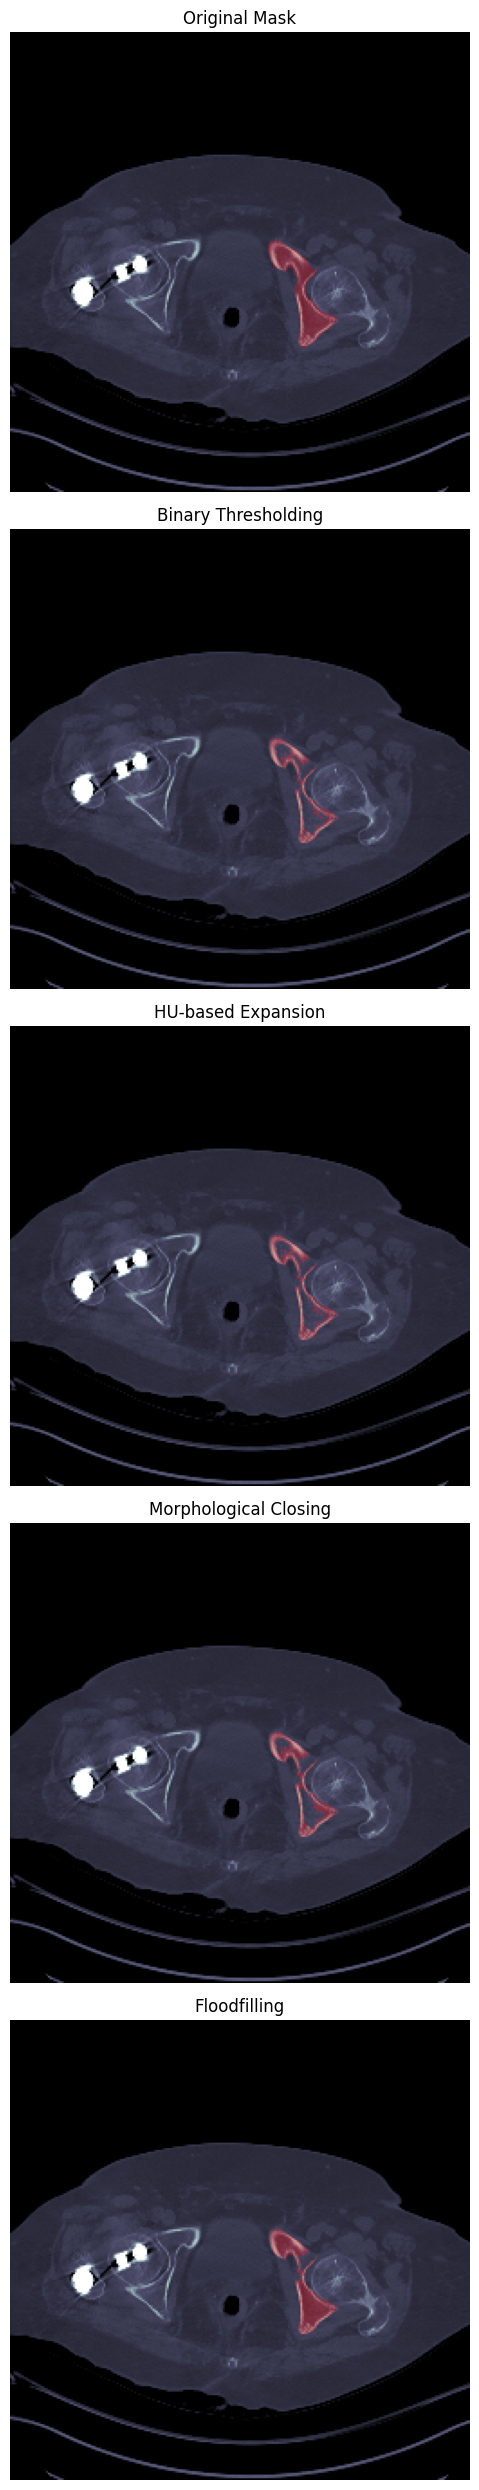

Slice 191: HU-based expansion added 71 voxels (> 40); reverting to mask after binary thresholding.
3D connected components found: 3
Longest run of slices with ≥2 objects: 18 slices (z=154 to z=171)
Most superior slice of obturator foramen: z=171
Inferior bound: z=168
Acetabular roof at slice 192, setting superior bound = 198
Cleaning range: z=168 to z=198
Cleaning range: z=168 to z=198


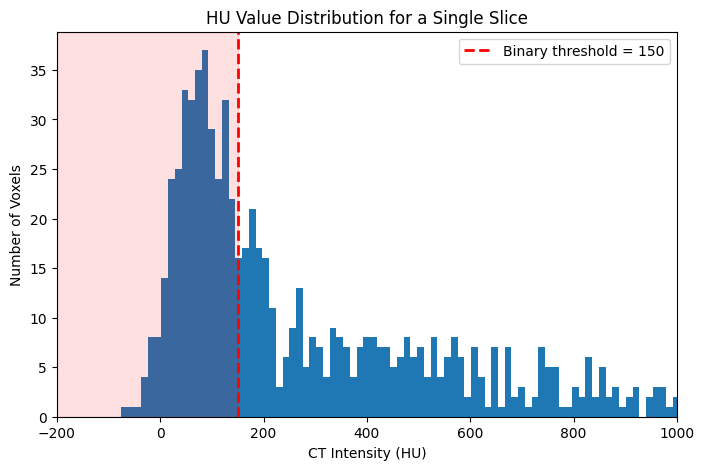

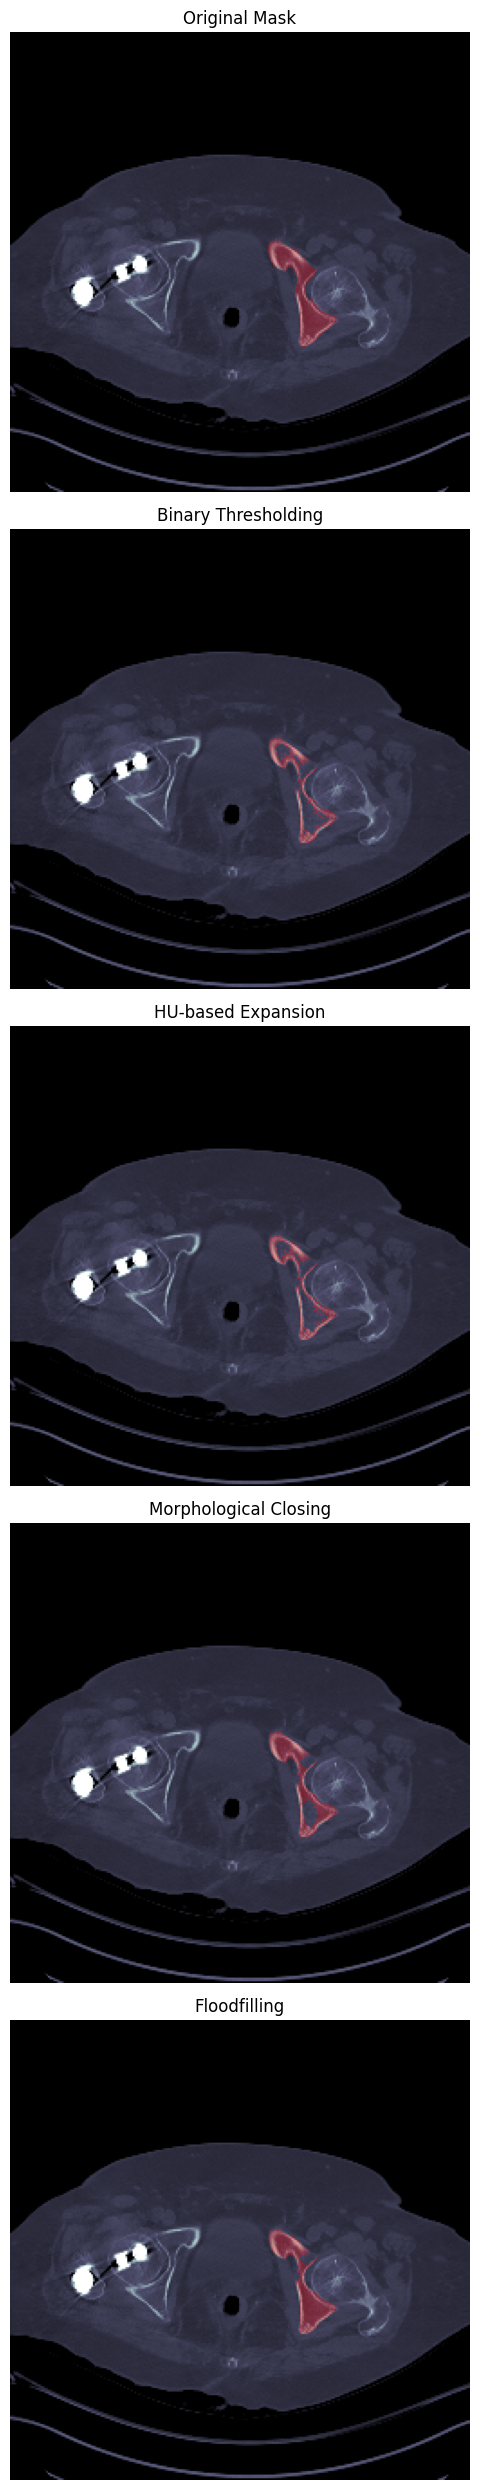

Slice 191: HU-based expansion added 71 voxels (> 40); reverting to mask after binary thresholding.
3D connected components found: 2


In [42]:
# Representative image: s0358-left (slice 174)
# - Original mask: grossly fine
# - Binary thresholding: multiple extremely large gaps in cortical bone
# - Expansion: none (added voxels = 0)
# - Morph close and floodfilling: none of the workflows fills up the void in the anterolateral aspect
# - Not replaced by fallback morph close method: voxel count difference (fallback - default) = 27
# - Not replaced by original mask: voxel count difference (original - processed) = 110
left_hip_mask_cleaned_s0358 = clean_mask_hip_visualize(ct_arr_s0358, left_hip_cropped_s0358, left_hip_pred_arr_rev_bi_s0358, slice_to_visualize=174, dilate_kernel=None, dilate_iters=1, erode_iters=1)
left_hip_mask_cleaned_fallback_s0358 = clean_mask_hip_visualize(ct_arr_s0358, left_hip_cropped_s0358, left_hip_pred_arr_rev_bi_s0358, slice_to_visualize=174, dilate_kernel=None, dilate_iters=3, erode_iters=3)

Slice 0: Solidity = 0.000
Slice 1: Solidity = 1.000
Slice 2: Solidity = 0.741
Slice 3: Solidity = 0.861
Slice 4: Solidity = 0.890
Slice 5: Solidity = 0.896
Slice 6: Solidity = 0.878
Slice 7: Solidity = 0.856
Slice 8: Solidity = 0.823
Slice 9: Solidity = 0.839
Slice 10: Solidity = 0.831
Slice 11: Solidity = 0.813
Slice 12: Solidity = 0.812
Slice 13: Solidity = 0.798
Slice 14: Solidity = 0.791
Slice 15: Solidity = 0.778
Slice 16: Solidity = 0.741
Slice 17: Solidity = 0.712
Slice 18: Solidity = 0.686
Slice 19: Solidity = 0.646
Slice 20: Solidity = 0.940
Slice 21: Solidity = 0.949
Slice 22: Solidity = 0.959
Slice 23: Solidity = 0.948
Slice 24: Solidity = 0.948
Slice 25: Solidity = 0.939
Slice 26: Solidity = 0.959
Slice 27: Solidity = 0.947
Slice 28: Solidity = 0.855
Slice 29: Solidity = 0.883
Slice 30: Solidity = 0.892
Slice 31: Solidity = 0.911
Slice 32: Solidity = 0.948
Slice 33: Solidity = 0.943
Slice 34: Solidity = 0.924
Slice 35: Solidity = 0.907
Slice 36: Solidity = 0.805
Slice 37: S

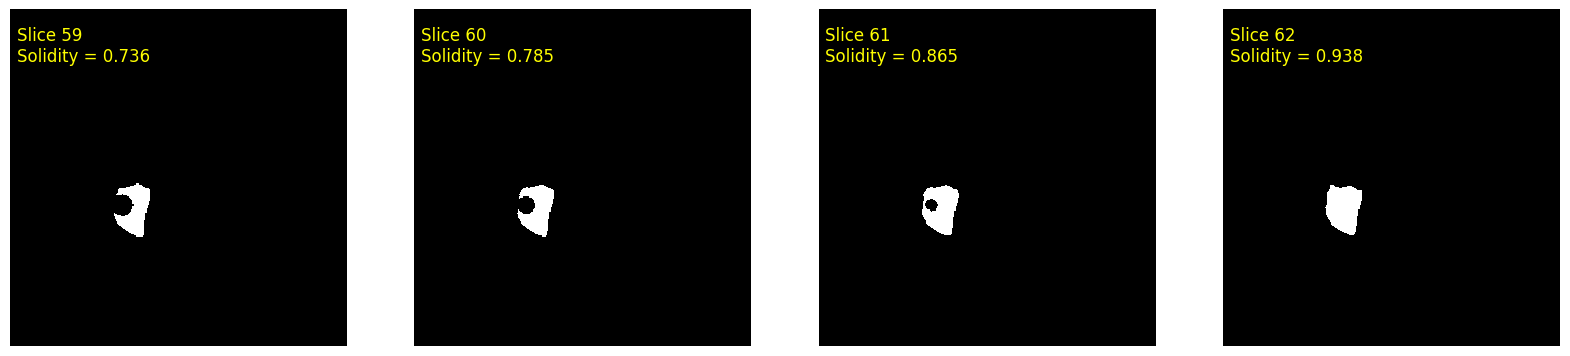

In [43]:
# Print out solidity 
print_solidity(right_hip_pred_arr_rev_bi_s0011)

# Display slices around superior bound and their respective solidity value
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
slices = [59, 60, 61, 62]
solidities = [0.736, 0.785, 0.865, 0.938]
for ax, s, sol in zip(axes, slices, solidities):
    ax.imshow(
        right_hip_pred_arr_rev_bi_s0011[s],
        cmap='gray',
        interpolation='none'
    )
    ax.text(
        0.02, 0.95,
        f"Slice {s}\nSolidity = {sol:.3f}",
        transform=ax.transAxes,
        color='yellow',
        fontsize=12,
        va='top',
        ha='left'
    )
    ax.axis('off')
plt.show()          